In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import dask.dataframe as dd
import dask.array as da
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [2]:
#getting the geometry frame. We want this to calculate the mean of upgrade om x and y positions
gcd_infile = dataio.I3File('/home/akatil/GeoCalibDetectorStatus_ICUpgrade.v58.mixed.V1.i3.bz2')

f_geo = gcd_infile
geo_frame = f_geo.pop_frame(icetray.I3Frame.Geometry)
geo = geo_frame['I3Geometry']

ux, uy, uz = get_mean_upgrade_positions(geo)

fCC = tables.open_file('../../../dataset_complete/merger/merged_CC_0.h5', mode='r')
fNC = tables.open_file('../../../dataset_complete/merger/merged_NC_0.h5', mode='r')

In [3]:
emin, emax = 0, 10
cmin, cmax = 0, 10

def get_boolean(f, interaction_type):
    if interaction_type == 0:
        energy = f.root.PrimaryEnergy.col('value')

    if interaction_type == 1:
        energy = f.root.SecondaryEnergy.col('value')

    renergy = f.root.RecoEnergy.col('value')
    total_charge = f.root.TotalCharge.col('value')

    energy_boolean = (energy >= emin) & (energy <= emax)
    reco_energy_boolean = (renergy >= emin) & (renergy <= emax)
    total_charge_boolean = (total_charge >= cmin) & (total_charge <= cmax)

    return energy_boolean, reco_energy_boolean, total_charge_boolean

In [4]:
event_booleanCC, reco_event_booleanCC, total_charge_booleanCC = get_boolean(fCC, 0)
event_booleanNC, reco_event_booleanNC, total_charge_booleanNC  = get_boolean(fNC, 1)

In [5]:
def seperability(CC, NC):
    total = len(CC) + len(NC)
    a = len(CC)/total
    b = len(NC)/total

    print(a, b, total)

    CC = CC[~np.isnan(CC)]
    NC = NC[~np.isnan(NC)]

    ks_statistic_true, pvalue_true = ks_2samp(CC, NC)

    combined_min = min(CC.min(), NC.min())
    combined_max = max(CC.max(), NC.max())

    n_bins = 100
    bin_edges = np.linspace(combined_min, combined_max, n_bins + 1)

    histCC, bin_edgesCC = np.histogram(CC, bins = bin_edges, density=True)
    histNC, bin_edgesNC = np.histogram(NC, bins = bin_edges, density=True)

    #print(histCC, histNC)

    num = (histCC*np.diff(bin_edgesCC))*(histNC*np.diff(bin_edgesNC))
    denom = a*histCC*np.diff(bin_edgesCC) + b*histNC*np.diff(bin_edgesNC)

    val = num/denom
    
    return 1 - np.sum(val)

In [24]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC, energy=True):
    sep_var = []
    p_val = []
    bin_centers = []

    if energy:
        max_val = 10
    else:
        max_val = 30 #charge
    
    for i in range(0, max_val):#range(0, len(charge_val)-1):#
        qmin= i*10 #charge_val[i]#
        qmax= (i+1)*10 #charge_val[i+1]#
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len( xNC[maskNC]) != 0:

            CC = xCC[maskCC]
            NC = xNC[maskNC]
            #ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])

            CC = CC[~np.isnan(CC)]
            NC = NC[~np.isnan(NC)]


            total = len(CC) + len(NC)
            a = len(CC)/total
            b = len(NC)/total
        
            CC = CC[~np.isnan(CC)]
            NC = NC[~np.isnan(NC)]
        
            #ks_statistic_true, pvalue_true = ks_2samp(CC, NC)
        
            combined_min = min(CC.min(), NC.min())
            combined_max = max(CC.max(), NC.max())
        
            n_bins = 100
            bin_edges = np.linspace(combined_min, combined_max, n_bins + 1)
        
            histCC, bin_edgesCC = np.histogram(CC, bins = bin_edges, density=True)
            histNC, bin_edgesNC = np.histogram(NC, bins = bin_edges, density=True)
        
            num = (histCC*np.diff(bin_edgesCC))*(histNC*np.diff(bin_edgesNC))
            denom = a*histCC*np.diff(bin_edgesCC) + b*histNC*np.diff(bin_edgesNC)
        
            val = num/denom

            print(a, b, total, 1 - np.sum(val[~np.isnan(val)]))
            
            sep_var.append(1 - np.sum(val[~np.isnan(val)]))
            bin_centers.append(qmax-0.5) #append(qmax - 5)

    return sep_var, p_val, bin_centers

In [25]:
sep_var_beta1_true, p_val_beta1_true, bin_centers_beta1_true = get_statistic(fCC.root.Beta1.col('value'), 
                                                                             fNC.root.Beta1.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta1_reco, p_val_beta1_reco, bin_centers_beta1_reco = get_statistic(fCC.root.Beta1Reco.col('value'), 
                                                                             fNC.root.Beta1Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta2_true, p_val_beta2_true, bin_centers_beta2_true = get_statistic(fCC.root.Beta2.col('value'), 
                                                                             fNC.root.Beta2.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta2_reco, p_val_beta2_reco, bin_centers_beta2_reco = get_statistic(fCC.root.Beta2Reco.col('value'), 
                                                                             fNC.root.Beta2Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta3_true, p_val_beta3_true, bin_centers_beta3_true = get_statistic(fCC.root.Beta3.col('value'), 
                                                                             fNC.root.Beta3.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta3_reco, p_val_beta3_reco, bin_centers_beta3_reco = get_statistic(fCC.root.Beta3Reco.col('value'), 
                                                                             fNC.root.Beta3Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta4_true, p_val_beta4_true, bin_centers_beta4_true = get_statistic(fCC.root.Beta4.col('value'), 
                                                                             fNC.root.Beta4.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta4_reco, p_val_beta4_reco, bin_centers_beta4_reco = get_statistic(fCC.root.Beta4Reco.col('value'), 
                                                                             fNC.root.Beta4Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

sep_var_beta5_true, p_val_beta5_true, bin_centers_beta5_true = get_statistic(fCC.root.Beta5.col('value'), 
                                                                             fNC.root.Beta5.col('value'), 
                                                                             fCC.root.PrimaryEnergy.col("value"), 
                                                                             fNC.root.SecondaryEnergy.col("value"))

sep_var_beta5_reco, p_val_beta5_reco, bin_centers_beta5_reco = get_statistic(fCC.root.Beta5Reco.col('value'), 
                                                                             fNC.root.Beta5Reco.col('value'), 
                                                                             fCC.root.RecoEnergy.col("value"), 
                                                                             fNC.root.RecoEnergy.col("value"))

0.24264157321707505 0.757358426782925 343144 0.012383611211252643
0.23716969317470257 0.7628303068252974 79850 0.009377059419227063
0.29374192622362566 0.7062580737763743 27868 0.0027637229832316867
0.3252532561505065 0.6747467438494935 11056 0.012409861851750748
0.2895886421550783 0.7104113578449217 5494 0.0078170415356551
0.3607937462417318 0.6392062537582682 3326 0.02014852659712507
0.42775169535732915 0.5722483046426708 1917 0.03857722192124757
0.4403940886699507 0.5596059113300492 1015 0.03596640535055895
0.6061946902654868 0.3938053097345133 678 0.047081227366711276
0.8050139275766016 0.19498607242339833 359 0.1172586778360526
0.20958821435756178 0.7904117856424382 323105 0.00855758942162499
0.28760638408556505 0.712393615914435 96114 0.0008656269428977126
0.3683946655971122 0.6316053344028878 29919 0.0013400842383521905
0.44121233234628116 0.5587876676537189 11482 0.0020088232377515336
0.43627906976744185 0.5637209302325581 5375 0.006774135456172448
0.44599869876382564 0.5540013

/tmp/ipykernel_6903/419580274.py:49: RuntimeWarning: invalid value encountered in divide
  val = num/denom


0.24264157321707505 0.757358426782925 343144 0.012310538682636318
0.23716969317470257 0.7628303068252974 79850 0.001623069261595278
0.29374192622362566 0.7062580737763743 27868 0.000705025226929612
0.3252532561505065 0.6747467438494935 11056 0.007751268757221874
0.2895886421550783 0.7104113578449217 5494 0.004096348338059719
0.3607937462417318 0.6392062537582682 3326 0.022061384398150086
0.42775169535732915 0.5722483046426708 1917 0.028570507487759023
0.4403940886699507 0.5596059113300492 1015 0.03606134184196519
0.6061946902654868 0.3938053097345133 678 0.05256802399706062
0.8050139275766016 0.19498607242339833 359 0.08250531162276031
0.20958821435756178 0.7904117856424382 323105 0.0074799402753731314
0.28760638408556505 0.712393615914435 96114 0.0009212330552186287
0.3683946655971122 0.6316053344028878 29919 0.0012752886394491458
0.44121233234628116 0.5587876676537189 11482 0.0016824065884161188
0.43627906976744185 0.5637209302325581 5375 0.004761950959057515
0.44599869876382564 0.55

In [26]:
csep_var_beta1_true, cp_val_beta1_true, cbin_centers_beta1_true = get_statistic(fCC.root.Beta1.col('value'), 
                                                                             fNC.root.Beta1.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta1_reco, cp_val_beta1_reco, cbin_centers_beta1_reco = get_statistic(fCC.root.Beta1Reco.col('value'), 
                                                                             fNC.root.Beta1Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta2_true, cp_val_beta2_true, cbin_centers_beta2_true = get_statistic(fCC.root.Beta2.col('value'), 
                                                                             fNC.root.Beta2.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta2_reco, cp_val_beta2_reco, cbin_centers_beta2_reco = get_statistic(fCC.root.Beta2Reco.col('value'), 
                                                                             fNC.root.Beta2Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta3_true, cp_val_beta3_true, cbin_centers_beta3_true = get_statistic(fCC.root.Beta3.col('value'), 
                                                                             fNC.root.Beta3.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta3_reco, cp_val_beta3_reco, cbin_centers_beta3_reco = get_statistic(fCC.root.Beta3Reco.col('value'), 
                                                                             fNC.root.Beta3Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta4_true, cp_val_beta4_true, cbin_centers_beta4_true = get_statistic(fCC.root.Beta4.col('value'), 
                                                                             fNC.root.Beta4.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta4_reco, cp_val_beta4_reco, cbin_centers_beta4_reco = get_statistic(fCC.root.Beta4Reco.col('value'), 
                                                                             fNC.root.Beta4Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta5_true, cp_val_beta5_true, cbin_centers_beta5_true = get_statistic(fCC.root.Beta5.col('value'), 
                                                                             fNC.root.Beta5.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

csep_var_beta5_reco, cp_val_beta5_reco, cbin_centers_beta5_reco = get_statistic(fCC.root.Beta5Reco.col('value'), 
                                                                             fNC.root.Beta5Reco.col('value'), 
                                                                             fCC.root.TotalCharge.col("value"), 
                                                                             fNC.root.TotalCharge.col("value"), energy=False)

0.0892998130064409 0.9107001869935591 24065 0.006914153001132628
0.1784056695539395 0.8215943304460605 107945 0.0029192855831142728
0.23103717648264116 0.7689628235173589 78087 0.003470571233905373
0.24307821665231927 0.7569217833476807 49951 0.0023498379100985733
0.2556061566841529 0.7443938433158471 34694 0.008494350244281357
0.2560720105532707 0.7439279894467292 25774 0.006218764844866831
0.2637346509466269 0.7362653490533732 20441 0.009510789213719284
0.26934906785512525 0.7306509321448748 15931 0.0021913707694584117
0.2802056555269923 0.7197943444730077 13226 0.003425118561860785
0.2909421939007738 0.7090578060992262 10985 0.0008478354659783305
0.29590372087887823 0.7040962791211218 9057 0.0013152486885911197
0.30086282355883454 0.6991371764411655 7997 0.009791832783277221
0.3188704221209001 0.6811295778790999 6799 0.0024303866691811615
0.311820652173913 0.6881793478260869 5888 0.016061031132145853
0.33403121431290445 0.6659687856870955 5254 0.008321876120880978
0.3412489006156552

/tmp/ipykernel_6903/419580274.py:49: RuntimeWarning: invalid value encountered in divide
  val = num/denom


0.0892998130064409 0.9107001869935591 24065 0.004940794308414542
0.1784056695539395 0.8215943304460605 107945 0.0014771770524633077
0.23103717648264116 0.7689628235173589 78087 0.0013888629801891428
0.24307821665231927 0.7569217833476807 49951 0.0011225113261663644
0.2556061566841529 0.7443938433158471 34694 0.0016041825046156921
0.2560720105532707 0.7439279894467292 25774 0.0004530365577289919
0.2637346509466269 0.7362653490533732 20441 0.0003948884385158724
0.26934906785512525 0.7306509321448748 15931 0.0008390162632753162
0.2802056555269923 0.7197943444730077 13226 0.0030932765036393306
0.2909421939007738 0.7090578060992262 10985 0.0018804226565573012
0.29590372087887823 0.7040962791211218 9057 0.00019026562237889344
0.30086282355883454 0.6991371764411655 7997 0.006771917706156927
0.3188704221209001 0.6811295778790999 6799 0.0025132321894005827
0.311820652173913 0.6881793478260869 5888 0.007437142174768541
0.33403121431290445 0.6659687856870955 5254 0.005455235566868
0.3412489006156

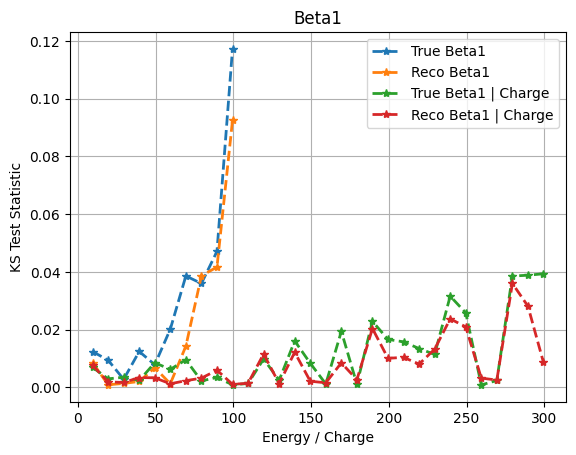

In [29]:
plt.plot(bin_centers_beta1_true, sep_var_beta1_true, '*--', linewidth=2, label='True Beta1')
plt.plot(bin_centers_beta1_reco, sep_var_beta1_reco, '*--', linewidth=2, label='Reco Beta1')
plt.plot(cbin_centers_beta1_true, csep_var_beta1_true, '*--', linewidth=2, label='True Beta1 | Charge')
plt.plot(cbin_centers_beta1_reco, csep_var_beta1_reco, '*--', linewidth=2, label='Reco Beta1 | Charge')
plt.title('Beta1')
plt.xlabel('Energy / Charge')
plt.ylabel('KS Test Statistic')
plt.legend()
plt.grid(True)

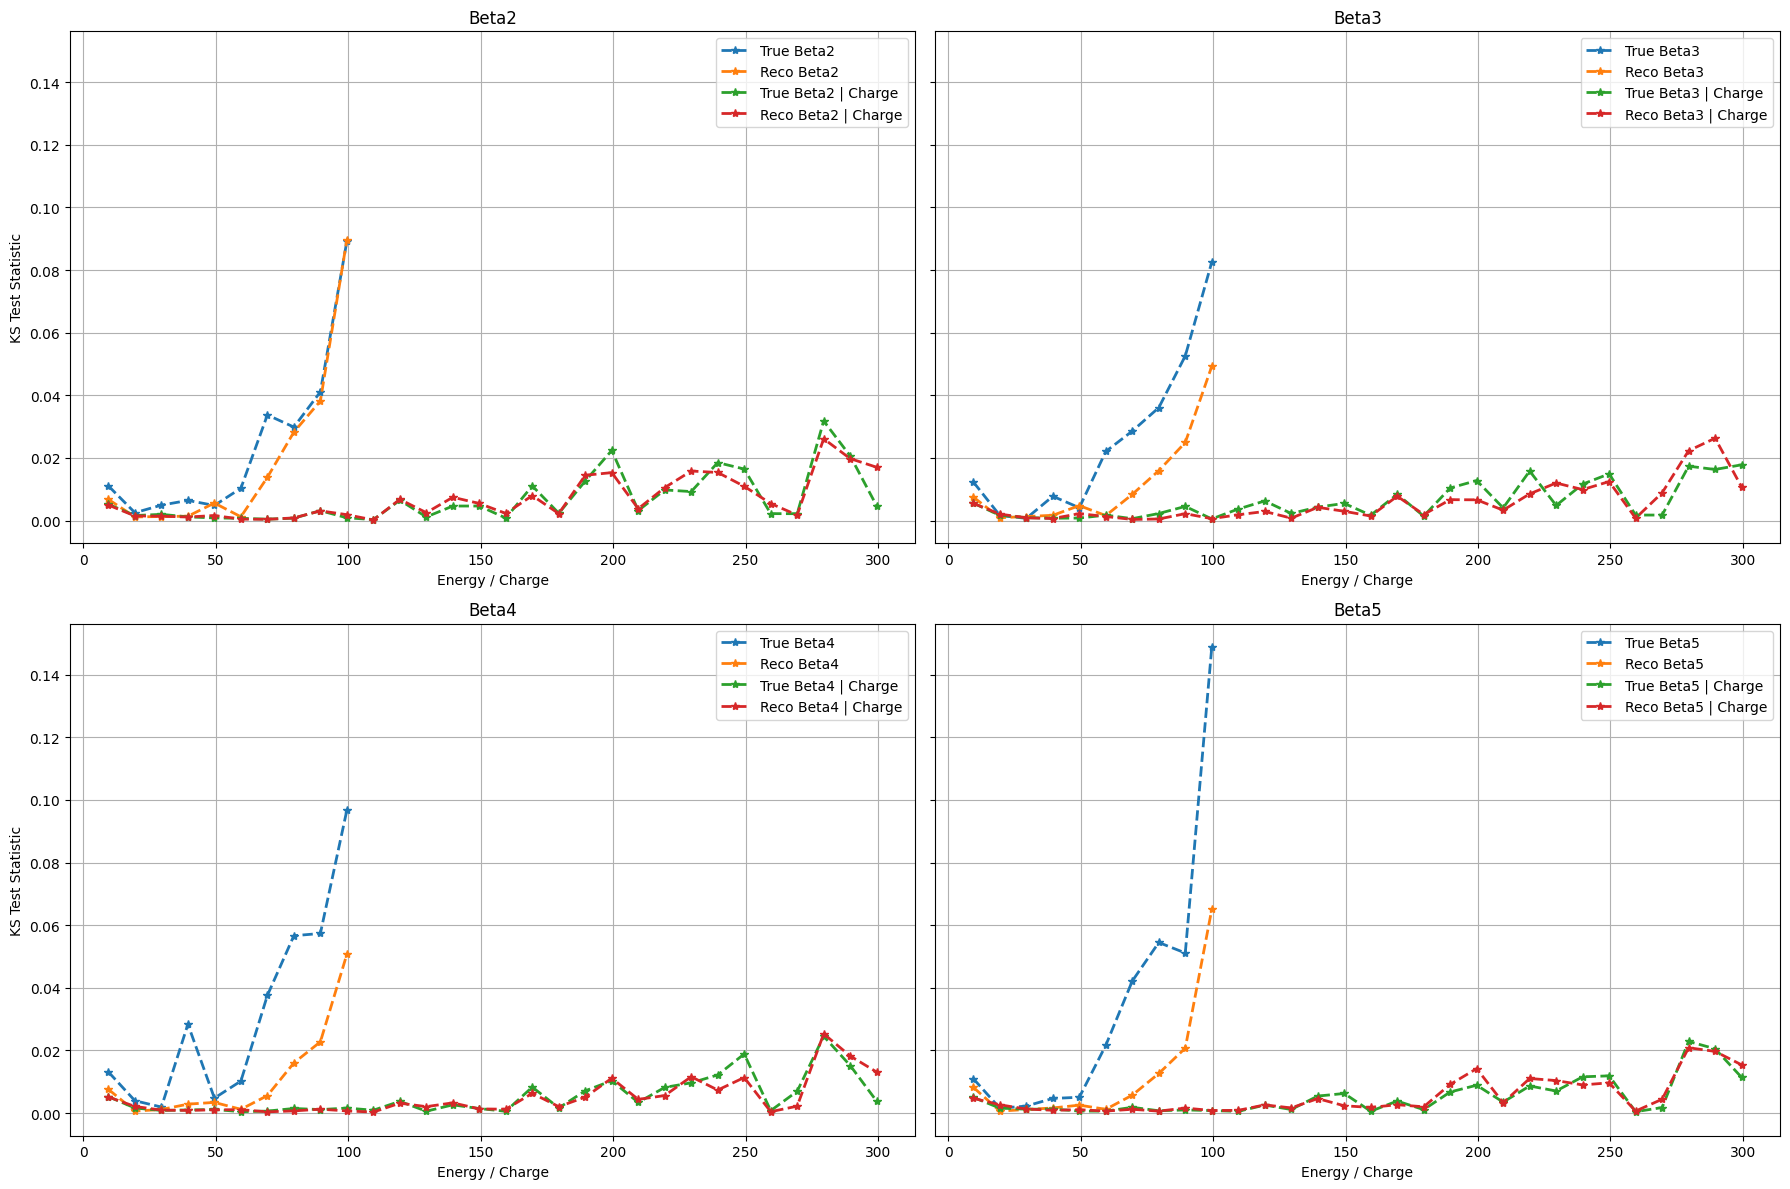

In [28]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12), sharey=True)

# Subplot 1: Angle
axs[0, 0].plot(bin_centers_beta2_true, sep_var_beta2_true, '*--', linewidth=2, label='True Beta2')
axs[0, 0].plot(bin_centers_beta2_reco, sep_var_beta2_reco, '*--', linewidth=2, label='Reco Beta2')
axs[0, 0].plot(cbin_centers_beta2_true, csep_var_beta2_true, '*--', linewidth=2, label='True Beta2 | Charge')
axs[0, 0].plot(cbin_centers_beta2_reco, csep_var_beta2_reco, '*--', linewidth=2, label='Reco Beta2 | Charge')
axs[0, 0].set_title('Beta2')
axs[0, 0].set_xlabel('Energy / Charge')
axs[0, 0].set_ylabel('KS Test Statistic')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Subplot 2: Time Resolution
axs[0, 1].plot(bin_centers_beta3_true, sep_var_beta3_true, '*--', linewidth=2, label='True Beta3')
axs[0, 1].plot(bin_centers_beta3_reco, sep_var_beta3_reco, '*--', linewidth=2, label='Reco Beta3')
axs[0, 1].plot(cbin_centers_beta3_true, csep_var_beta3_true, '*--', linewidth=2, label='True Beta3 | Charge')
axs[0, 1].plot(cbin_centers_beta3_reco, csep_var_beta3_reco, '*--', linewidth=2, label='Reco Beta3 | Charge')
axs[0, 1].set_title('Beta3')
axs[0, 1].set_xlabel('Energy / Charge')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Subplot 3: Distance
axs[1, 0].plot(bin_centers_beta4_true, sep_var_beta4_true, '*--', linewidth=2, label='True Beta4')
axs[1, 0].plot(bin_centers_beta4_reco, sep_var_beta4_reco, '*--', linewidth=2, label='Reco Beta4')
axs[1, 0].plot(cbin_centers_beta4_true, csep_var_beta4_true, '*--', linewidth=2, label='True Beta4 | Charge')
axs[1, 0].plot(cbin_centers_beta4_reco, csep_var_beta4_reco, '*--', linewidth=2, label='Reco Beta4 | Charge')
axs[1, 0].set_title('Beta4')
axs[1, 0].set_xlabel('Energy / Charge')
axs[1, 0].set_ylabel('KS Test Statistic')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Subplot 4: Beta1
axs[1, 1].plot(bin_centers_beta5_true, sep_var_beta5_true, '*--', linewidth=2, label='True Beta5')
axs[1, 1].plot(bin_centers_beta5_reco, sep_var_beta5_reco, '*--', linewidth=2, label='Reco Beta5')
axs[1, 1].plot(cbin_centers_beta5_true, csep_var_beta5_true, '*--', linewidth=2, label='True Beta5 | Charge')
axs[1, 1].plot(cbin_centers_beta5_reco, csep_var_beta5_reco, '*--', linewidth=2, label='Reco Beta5 | Charge')
axs[1, 1].set_title('Beta5')
axs[1, 1].set_xlabel('Energy / Charge')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()